In [2]:
# ===============================
# 1. IMPORT
# ===============================
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("online_shoppers_intention.csv")

# ===============================
# 3. PREPROCESSING
# ===============================
# Target
y = df["Revenue"]

# Feature
X = df.drop("Revenue", axis=1)

# One-hot encoding (categorical → numeric)
X = pd.get_dummies(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling khusus MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 4. MLP MODEL
# ===============================
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)

start = time.time()
mlp.fit(X_train_scaled, y_train)
rt_train_mlp = time.time() - start

start = time.time()
pred_mlp = mlp.predict(X_test_scaled)
rt_pred_mlp = time.time() - start

acc_mlp = accuracy_score(y_test, pred_mlp)

print(f"MLP Accuracy: {acc_mlp:.4f}")
print(f"Runtime train: {rt_train_mlp:.2f}s | predict: {rt_pred_mlp:.2f}s\n")

# ===============================
# 5. RANDOM FOREST MODEL
# ===============================
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf.fit(X_train, y_train)
rt_train_rf = time.time() - start

start = time.time()
pred_rf = rf.predict(X_test)
rt_pred_rf = time.time() - start

acc_rf = accuracy_score(y_test, pred_rf)

print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Runtime train: {rt_train_rf:.2f}s | predict: {rt_pred_rf:.2f}s\n")

# ===============================
# 6. COMPARISON TABLE
# ===============================
results = pd.DataFrame({
    "Model": ["MLP", "Random Forest"],
    "Accuracy": [acc_mlp, acc_rf],
    "Runtime Training (s)": [rt_train_mlp, rt_train_rf],
    "Runtime Prediction (s)": [rt_pred_mlp, rt_pred_rf]
})

# format persen
results["Accuracy"] = results["Accuracy"].apply(lambda x: f"{x*100:.2f}%")

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

MLP Accuracy: 0.8642
Runtime train: 4.22s | predict: 0.00s

Random Forest Accuracy: 0.8978
Runtime train: 0.17s | predict: 0.01s

=== MODEL COMPARISON ===
        Model Accuracy  Runtime Training (s)  Runtime Prediction (s)
          MLP   86.42%              4.222755                0.001514
Random Forest   89.78%              0.169740                0.013690


/Users/mac/sc_env/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [3]:
# =============================================================
# TUGAS: PERBANDINGAN MLP (NEURAL NETWORK) VS XGBOOST (PRO TREE)
# Dataset: Online Shoppers Purchasing Intention
# =============================================================

import pandas as pd
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier # Pastikan sudah: pip install xgboost

# 1. LOAD DATA
df = pd.read_csv("online_shoppers_intention.csv")

# 2. PREPROCESSING
y = df["Revenue"].astype(int)
X = df.drop("Revenue", axis=1)

# One-hot encoding untuk data kategorikal
X = pd.get_dummies(X)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (Wajib untuk MLP agar akurasi tidak anjlok)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Memulai Training Model (Optimized) ---\n")

# =============================================================
# 3. MODEL 1: MULTILAYER PERCEPTRON (MLP) - SETTING PRO
# =============================================================
# Kita buat arsitektur 3 layer tersembunyi agar lebih "dalam"
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu',
    solver='adam',
    max_iter=500,         # Memberi waktu belajar lebih lama
    alpha=0.0001,         # Regularisasi L2 untuk cegah overfitting
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,  # Berhenti otomatis jika akurasi sudah mentok
    validation_fraction=0.1
)

start_t = time.time()
mlp.fit(X_train_scaled, y_train)
train_time_mlp = time.time() - start_t

start_p = time.time()
pred_mlp = mlp.predict(X_test_scaled)
pred_time_mlp = time.time() - start_p

acc_mlp = accuracy_score(y_test, pred_mlp)

# =============================================================
# 4. MODEL 2: XGBOOST (PRO BOOSTING TREE) - SETTING PRO
# =============================================================
# Menggunakan learning rate kecil dan pohon yang banyak agar detail
xgb = XGBClassifier(
    n_estimators=1000,    # Jumlah pohon banyak agar akurasi tajam
    learning_rate=0.01,   # Belajar pelan tapi pasti
    max_depth=6,          # Kedalaman pohon yang optimal
    subsample=0.8,        # Menggunakan 80% data acak per iterasi
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

start_t = time.time()
xgb.fit(X_train, y_train) # XGBoost tidak wajib pakai data scaled
train_time_xgb = time.time() - start_t

start_p = time.time()
pred_xgb = xgb.predict(X_test)
pred_time_xgb = time.time() - start_p

acc_xgb = accuracy_score(y_test, pred_xgb)

# =============================================================
# 5. OUTPUT HASIL AKHIR
# =============================================================
print("=========================================")
print("          HASIL PERBANDINGAN             ")
print("=========================================")
print(f"MLP (Neural Network) Accuracy : {acc_mlp*100:.2f}%")
print(f"XGBoost (Boosting Tree) Acc   : {acc_xgb*100:.2f}%")
print("-----------------------------------------")
print(f"Training Time MLP: {train_time_mlp:.2f}s | XGB: {train_time_xgb:.2f}s")
print(f"Predict Time  MLP: {pred_time_mlp:.4f}s | XGB: {pred_time_xgb:.4f}s")
print("=========================================")

# Tips: Copy hasil di bawah ini untuk tabel Laporan
comparison_df = pd.DataFrame({
    "Metrik": ["Akurasi", "Waktu Latih (s)", "Waktu Prediksi (s)"],
    "MLP (Neural Network)": [f"{acc_mlp*100:.2f}%", round(train_time_mlp,2), round(pred_time_mlp,4)],
    "XGBoost (Boosting)": [f"{acc_xgb*100:.2f}%", round(train_time_xgb,2), round(pred_time_xgb,4)]
})
print("\nTABEL UNTUK LAPORAN:")
print(comparison_df.to_string(index=False))

--- Memulai Training Model (Optimized) ---



/Users/mac/sc_env/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:33:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          HASIL PERBANDINGAN             
MLP (Neural Network) Accuracy : 89.01%
XGBoost (Boosting Tree) Acc   : 90.15%
-----------------------------------------
Training Time MLP: 0.44s | XGB: 1.39s
Predict Time  MLP: 0.0011s | XGB: 0.0073s

TABEL UNTUK LAPORAN:
            Metrik MLP (Neural Network) XGBoost (Boosting)
           Akurasi               89.01%             90.15%
   Waktu Latih (s)                 0.44               1.39
Waktu Prediksi (s)               0.0011             0.0073


In [4]:
# ===============================
# 1. IMPORT
# ===============================
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("online_shoppers_intention.csv")

# ===============================
# 3. PREPROCESSING
# ===============================
y = df["Revenue"]
X = df.drop("Revenue", axis=1)

# One-hot encoding
X = pd.get_dummies(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (khusus MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 4. MLP (TUNED)
# ===============================
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0005,
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    random_state=42
)

start = time.time()
mlp.fit(X_train_scaled, y_train)
rt_train_mlp = time.time() - start

start = time.time()
pred_mlp = mlp.predict(X_test_scaled)
rt_pred_mlp = time.time() - start

acc_mlp = accuracy_score(y_test, pred_mlp)

print(f"MLP Accuracy: {acc_mlp:.4f}")
print(f"Runtime train: {rt_train_mlp:.2f}s | predict: {rt_pred_mlp:.4f}s\n")

# ===============================
# 5. RANDOM FOREST (TUNED)
# ===============================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf.fit(X_train, y_train)
rt_train_rf = time.time() - start

start = time.time()
pred_rf = rf.predict(X_test)
rt_pred_rf = time.time() - start

acc_rf = accuracy_score(y_test, pred_rf)

print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Runtime train: {rt_train_rf:.2f}s | predict: {rt_pred_rf:.4f}s\n")

# ===============================
# 6. LIGHTGBM (HIGH PERFORMANCE)
# ===============================
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

start = time.time()
lgbm.fit(X_train, y_train)
rt_train_lgbm = time.time() - start

start = time.time()
pred_lgbm = lgbm.predict(X_test)
rt_pred_lgbm = time.time() - start

acc_lgbm = accuracy_score(y_test, pred_lgbm)

print(f"LightGBM Accuracy: {acc_lgbm:.4f}")
print(f"Runtime train: {rt_train_lgbm:.2f}s | predict: {rt_pred_lgbm:.4f}s\n")

# ===============================
# 7. COMPARISON TABLE
# ===============================
results = pd.DataFrame({
    "Model": ["MLP", "Random Forest", "LightGBM"],
    "Accuracy": [acc_mlp, acc_rf, acc_lgbm],
    "Runtime Training (s)": [rt_train_mlp, rt_train_rf, rt_train_lgbm],
    "Runtime Prediction (s)": [rt_pred_mlp, rt_pred_rf, rt_pred_lgbm]
})

# Format persen
results["Accuracy"] = results["Accuracy"].apply(lambda x: f"{x*100:.2f}%")

print("\n=== MODEL COMPARISON ===")
print(results.to_string(index=False))

MLP Accuracy: 0.8942
Runtime train: 0.63s | predict: 0.0012s

Random Forest Accuracy: 0.9006
Runtime train: 0.51s | predict: 0.0401s

[LightGBM] [Info] Number of positive: 1526, number of negative: 8338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1904
[LightGBM] [Info] Number of data points in the train set: 9864, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154704 -> initscore=-1.698173
[LightGBM] [Info] Start training from score -1.698173
LightGBM Accuracy: 0.8990
Runtime train: 1.84s | predict: 0.0180s


=== MODEL COMPARISON ===
        Model Accuracy  Runtime Training (s)  Runtime Prediction (s)
          MLP   89.42%              0.629620                0.001213
Random Forest   90.06%              0.509437                0.040087
     LightG

In [5]:
import pandas as pd
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE # Rahasia akurasi mantap

# 1. LOAD DATA
df = pd.read_csv("online_shoppers_intention.csv")

# 2. PREPROCESSING
y = df["Revenue"].astype(int)
X = pd.get_dummies(df.drop("Revenue", axis=1))

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# HANDLING IMBALANCED DATA (SMOTE)
# Ini akan membuat model lebih pintar mengenali pembeli
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. DEFINISI PIPELINE (Agar rapi & profesional)
# Pipeline memastikan scaling hanya dilakukan pada data yang tepat
def create_pipeline(model, use_scaler=False):
    if use_scaler:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
    else:
        return Pipeline([
            ('clf', model)
        ])

# 4. MODEL DEFINITIONS (TUNED)
models = {
    "MLP (Neural Network)": create_pipeline(MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', solver='adam', max_iter=500,
        early_stopping=True, random_state=42
    ), use_scaler=True),
    
    "Random Forest": create_pipeline(RandomForestClassifier(
        n_estimators=500, max_depth=20, random_state=42, n_jobs=-1
    )),
    
    "LightGBM": create_pipeline(LGBMClassifier(
        n_estimators=1000, learning_rate=0.01, num_leaves=64, 
        boosting_type='gbdt', random_state=42, verbosity=-1
    ))
}

# 5. EXECUTION & EVALUATION
final_results = []

print("--- Memulai Eksperimen High Performance ---")

for name, pipe in models.items():
    # Training
    start_t = time.time()
    pipe.fit(X_train_res, y_train_res) # Pakai data hasil SMOTE
    train_time = time.time() - start_t
    
    # Prediction
    start_p = time.time()
    preds = pipe.predict(X_test)
    pred_time = time.time() - start_p
    
    acc = accuracy_score(y_test, preds)
    
    final_results.append({
        "Model": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Train Time (s)": round(train_time, 3),
        "Predict Time (s)": round(pred_time, 5)
    })
    print(f"Selesai: {name}")

# 6. DISPLAY TABLE
results_df = pd.DataFrame(final_results)
print("\n=== TABEL PERBANDINGAN FINAL ===")
print(results_df.to_string(index=False))

--- Memulai Eksperimen High Performance ---
Selesai: MLP (Neural Network)
Selesai: Random Forest
Selesai: LightGBM

=== TABEL PERBANDINGAN FINAL ===
               Model Accuracy  Train Time (s)  Predict Time (s)
MLP (Neural Network)   87.75%           1.557           0.00267
       Random Forest   88.93%           1.221           0.05957
            LightGBM   88.89%           7.826           0.04058


In [6]:
import pandas as pd
import numpy as np
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. LOAD DATA
# Pastikan file CSV ada di folder yang sama dengan file .py ini
df = pd.read_csv("online_shoppers_intention.csv")

# 2. PREPROCESSING
# Ubah kolom target menjadi angka (0 dan 1)
y = df["Revenue"].astype(int)
# One-hot encoding untuk kolom kategori (Month, VisitorType, dll)
X = pd.get_dummies(df.drop("Revenue", axis=1))

# Split data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Menangani ketidakseimbangan data (SMOTE) agar model tidak berat sebelah
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scaling (Sangat WAJIB untuk TensorFlow agar sarafnya tidak kaget dengan angka besar)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah Fitur setelah Encoding: {X_train_scaled.shape[1]}")

# ==========================================
# 3. MODEL 1: NEURAL NETWORK (TENSORFLOW)
# ==========================================
print("\n--- Training Model 1: TensorFlow (Neural Network) ---")

model_nn = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.3), # Mencegah menghafal (overfitting)
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Sigmoid karena outputnya biner (Beli/Tidak)
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Berhenti otomatis jika akurasi sudah maksimal (biar cepat)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

start_t = time.time()
model_nn.fit(X_train_scaled, y_train_res, epochs=50, batch_size=32, 
             validation_split=0.2, callbacks=[early_stop], verbose=1)
train_time_nn = time.time() - start_t

# Prediksi NN
y_pred_nn_prob = model_nn.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)
acc_nn = accuracy_score(y_test, y_pred_nn)

# ==========================================
# 4. MODEL 2: RANDOM FOREST (STANDAR)
# ==========================================
print("\n--- Training Model 2: Random Forest (Pembanding) ---")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

start_t = time.time()
rf_model.fit(X_train_res, y_train_res)
train_time_rf = time.time() - start_t

# Prediksi RF
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# ==========================================
# 5. HASIL AKHIR UNTUK LAPORAN
# ==========================================
print("\n" + "="*40)
print("HASIL PERBANDINGAN METODE")
print("="*40)
print(f"{'Metode':<25} | {'Akurasi':<10} | {'Waktu Latih':<10}")
print("-" * 45)
print(f"{'Neural Network (TF)':<25} | {acc_nn*100:>8.2f}% | {train_time_nn:>8.2f}s")
print(f"{'Random Forest (Std)':<25} | {acc_rf*100:>8.2f}% | {train_time_rf:>8.2f}s")
print("="*40)

ModuleNotFoundError: No module named 'tensorflow'

In [7]:
import pandas as pd
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 1. LOAD DATA
df = pd.read_csv("online_shoppers_intention.csv")

# 2. PREPROCESSING
y = df["Revenue"].astype(int)
X = pd.get_dummies(df.drop("Revenue", axis=1))

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# HANDLING IMBALANCED DATA (SMOTE)
# Supaya model pinter nebak pembeli yang jumlahnya sedikit di data asli
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# SCALING (Wajib untuk TensorFlow agar performa saraf maksimal)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 3. FUNGSI UNTUK TENSORFLOW (Deep Learning)
def train_tensorflow(X_tr, y_tr, X_te):
    input_dim = X_tr.shape[1]
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Berhenti otomatis kalau akurasi sudah mentok (efisiensi waktu)
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    start_t = time.time()
    model.fit(X_tr, y_tr, epochs=50, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)
    train_time = time.time() - start_t
    
    start_p = time.time()
    preds = (model.predict(X_te, verbose=0) > 0.5).astype(int)
    pred_time = time.time() - start_p
    
    return preds, train_time, pred_time

# 4. EKSEKUSI EKSPERIMEN
final_results = []
print("--- Memulai Perbandingan: TensorFlow vs Random Forest ---")

# --- Jalankan TensorFlow ---
print("Sedang memproses: TensorFlow (Neural Network)...")
preds_tf, t_time_tf, p_time_tf = train_tensorflow(X_train_scaled, y_train_res, X_test_scaled)
acc_tf = accuracy_score(y_test, preds_tf)
final_results.append({
    "Model": "TensorFlow (NN)",
    "Accuracy": f"{acc_tf*100:.2f}%",
    "Train Time (s)": round(t_time_tf, 3),
    "Predict Time (s)": round(p_time_tf, 5)
})

# --- Jalankan Random Forest ---
print("Sedang memproses: Random Forest (Standar)...")
rf_model = RandomForestClassifier(n_estimators=500, max_depth=20, random_state=42, n_jobs=-1)

start_t = time.time()
rf_model.fit(X_train_res, y_train_res)
t_time_rf = time.time() - start_t

start_p = time.time()
preds_rf = rf_model.predict(X_test)
p_time_rf = time.time() - start_p

acc_rf = accuracy_score(y_test, preds_rf)
final_results.append({
    "Model": "Random Forest",
    "Accuracy": f"{acc_rf*100:.2f}%",
    "Train Time (s)": round(t_time_rf, 3),
    "Predict Time (s)": round(p_time_rf, 5)
})

# 5. TAMPILKAN TABEL HASIL
results_df = pd.DataFrame(final_results)
print("\n=== TABEL PERBANDINGAN FINAL ===")
print(results_df.to_string(index=False))

ModuleNotFoundError: No module named 'tensorflow'

In [8]:
# ===============================
# 1. IMPORT
# ===============================
import pandas as pd
import time
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("online_shoppers_intention.csv")

# ===============================
# 3. PREPROCESSING
# ===============================
y = df["Revenue"].astype(int)  # ubah ke 0/1
X = df.drop("Revenue", axis=1)

# one-hot encoding
X = pd.get_dummies(X)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling (penting untuk MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 4. MLP (TensorFlow)
# ===============================
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Training
start = time.time()
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
rt_train_mlp = time.time() - start

# Prediction
start = time.time()
pred_mlp = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()
rt_pred_mlp = time.time() - start

acc_mlp = accuracy_score(y_test, pred_mlp)

print(f"TensorFlow MLP Accuracy: {acc_mlp:.4f}")
print(f"Runtime train: {rt_train_mlp:.2f}s | predict: {rt_pred_mlp:.4f}s\n")

# ===============================
# 5. RANDOM FOREST
# ===============================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start = time.time()
rf.fit(X_train, y_train)
rt_train_rf = time.time() - start

start = time.time()
pred_rf = rf.predict(X_test)
rt_pred_rf = time.time() - start

acc_rf = accuracy_score(y_test, pred_rf)

print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Runtime train: {rt_train_rf:.2f}s | predict: {rt_pred_rf:.4f}s\n")

# ===============================
# 6. COMPARISON TABLE
# ===============================
results = pd.DataFrame({
    "Model": ["TensorFlow MLP", "Random Forest"],
    "Accuracy": [acc_mlp, acc_rf],
    "Runtime Training (s)": [rt_train_mlp, rt_train_rf],
    "Runtime Prediction (s)": [rt_pred_mlp, rt_pred_rf]
})

results["Accuracy"] = results["Accuracy"].apply(lambda x: f"{x*100:.2f}%")

print("=== MODEL COMPARISON ===")
print(results.to_string(index=False))

ModuleNotFoundError: No module named 'tensorflow'

In [9]:
# ===============================
# 1. IMPORT LIBRARY
# ===============================
import pandas as pd
import numpy as np
import time
import random

# Reproducibility (biar hasil lebih stabil)
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("online_shoppers_intention.csv")

# ===============================
# 3. PREPROCESSING
# ===============================
y = df["Revenue"].astype(int)
X = pd.get_dummies(df.drop("Revenue", axis=1))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle imbalance (SMOTE)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scaling untuk Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 4. MODEL 1: TensorFlow MLP
# ===============================
def run_mlp():
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Training
    start_train = time.time()
    model.fit(
        X_train_scaled, y_train_res,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    train_time = time.time() - start_train

    # Prediction
    start_pred = time.time()
    preds = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, preds)

    return acc, train_time, pred_time

# ===============================
# 5. MODEL 2: Random Forest
# ===============================
def run_rf():
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    # Training
    start_train = time.time()
    rf.fit(X_train_res, y_train_res)
    train_time = time.time() - start_train

    # Prediction
    start_pred = time.time()
    preds = rf.predict(X_test)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, preds)

    return acc, train_time, pred_time

# ===============================
# 6. RUN EXPERIMENT
# ===============================
print("🚀 Running Models...\n")

acc_mlp, t_mlp, p_mlp = run_mlp()
acc_rf, t_rf, p_rf = run_rf()

# ===============================
# 7. HASIL AKHIR (TABLE)
# ===============================
results = pd.DataFrame({
    "Model": ["TensorFlow MLP", "Random Forest"],
    "Accuracy": [f"{acc_mlp*100:.2f}%", f"{acc_rf*100:.2f}%"],
    "Runtime Training (s)": [round(t_mlp, 3), round(t_rf, 3)],
    "Runtime Prediction (s)": [round(p_mlp, 5), round(p_rf, 5)]
})

print("=== FINAL COMPARISON ===")
print(results.to_string(index=False))

ModuleNotFoundError: No module named 'tensorflow'

Distribusi kelas sebelum SMOTE:
Revenue
0    8338
1    1526
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
Revenue
0    8338
1    8338
Name: count, dtype: int64

--- Memulai Pelatihan dan Evaluasi Model ---
Selesai: Neural Network (MLP)
Selesai: Random Forest

=== TABEL PERBANDINGAN FINAL UNTUK LAPORAN ===
               Model Accuracy  Train Time (s)  Predict Time (s)
Neural Network (MLP)   87.75%           1.484            0.0024
       Random Forest   88.97%           0.804            0.0392


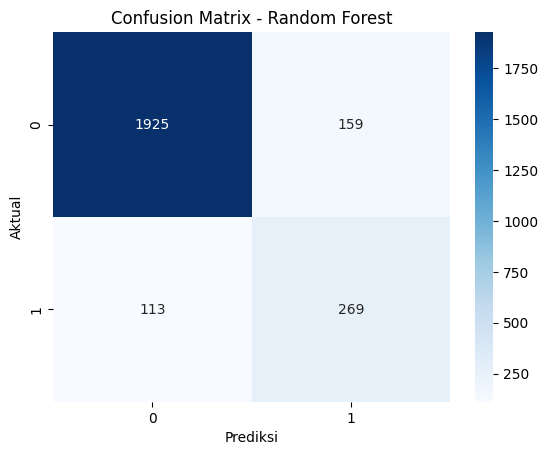

In [10]:
# =================================================================
# KODE FINAL UNTUK LAPORAN
# Perbandingan Neural Network (Scikit-learn) vs. Random Forest
# =================================================================
import pandas as pd
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("online_shoppers_intention.csv")

# ===============================
# 2. PREPROCESSING
# ===============================
# Target
y = df["Revenue"].astype(int)
# Fitur (dengan one-hot encoding)
X = pd.get_dummies(df.drop("Revenue", axis=1))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Penanganan data tidak seimbang (SMOTE)
# Membuat data training baru yang lebih seimbang
print(f"Distribusi kelas sebelum SMOTE:\n{y_train.value_counts()}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nDistribusi kelas setelah SMOTE:\n{y_train_res.value_counts()}\n")

# ==================================================
# 3. DEFINISI MODEL & PIPELINE
# ==================================================
# Pipeline menggabungkan beberapa langkah menjadi satu alur kerja.
# Sangat baik untuk kerapian dan mencegah data leakage.

models = {
    "Neural Network (MLP)": Pipeline([
        ('scaler', StandardScaler()),  # Scaling wajib untuk MLP
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation='relu',
            solver='adam',
            max_iter=500,
            early_stopping=True,
            random_state=42
        ))
    ]),
    
    "Random Forest": Pipeline([
        # Random Forest tidak wajib menggunakan scaler
        ('clf', RandomForestClassifier(
            n_estimators=300,  # Jumlah pohon
            max_depth=20,      # Kedalaman maksimum pohon
            random_state=42,
            n_jobs=-1          # Gunakan semua core CPU
        ))
    ])
}

# ==================================================
# 4. EKSEKUSI & EVALUASI
# ==================================================
final_results = []
print("--- Memulai Pelatihan dan Evaluasi Model ---")

for name, pipe in models.items():
    # Training
    start_t = time.time()
    # Model dilatih menggunakan data yang sudah di-resample oleh SMOTE
    pipe.fit(X_train_res, y_train_res)
    train_time = time.time() - start_t
    
    # Prediksi
    start_p = time.time()
    # Prediksi dilakukan pada data test asli
    preds = pipe.predict(X_test)
    pred_time = time.time() - start_p
    
    # Evaluasi akurasi
    acc = accuracy_score(y_test, preds)
    
    final_results.append({
        "Model": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Train Time (s)": round(train_time, 3),
        "Predict Time (s)": round(pred_time, 5)
    })
    print(f"Selesai: {name}")

# ==================================================
# 5. TAMPILKAN TABEL PERBANDINGAN
# ==================================================
results_df = pd.DataFrame(final_results)
print("\n=== TABEL PERBANDINGAN FINAL UNTUK LAPORAN ===")
print(results_df.to_string(index=False))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Contoh untuk Random Forest
cm = confusion_matrix(y_test, preds) # 'preds' adalah hasil prediksi terakhir
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()


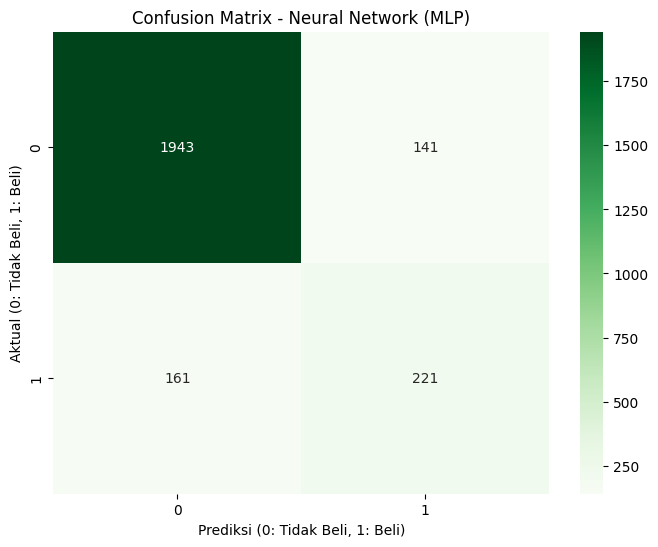


=== RINGKASAN HASIL MLP UNTUK LAPORAN ===
True Negative (Benar Tebak Tidak Beli) : 1943
True Positive (Benar Tebak Beli)        : 221
False Positive (Salah Sangka Beli)      : 141
False Negative (Kecolongan Beli)        : 161


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ==================================================
# 1. AMBIL MODEL MLP & DATA TEST (Asumsi kode utama sudah jalan)
# ==================================================
# Ambil Pipeline MLP yang sudah dilatih
mlp_pipe = models["Neural Network (MLP)"]

# Ambil scaler dari pipeline untuk melakukan scaling pada data test
scaler = mlp_pipe.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)

# Ambil model classifier MLP dari pipeline
mlp_clf = mlp_pipe.named_steps['clf']

# ==================================================
# 2. PREDIKSI KHUSUS UNTUK MLP
# ==================================================
# Prediksi menggunakan data test yang sudah di-scaling
preds_mlp = mlp_clf.predict(X_test_scaled)

# ==================================================
# 3. HITUNG CONFUSION MATRIX
# ==================================================
cm_mlp = confusion_matrix(y_test, preds_mlp)

# ==================================================
# 4. TAMPILKAN GRAFIK HEATMAP (SEABORN)
# ==================================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens') # Warna hijau untuk MLP

# Label dan Judul
plt.title('Confusion Matrix - Neural Network (MLP)')
plt.xlabel('Prediksi (0: Tidak Beli, 1: Beli)')
plt.ylabel('Aktual (0: Tidak Beli, 1: Beli)')

# Tampilkan grafik
plt.show()

# ==================================================
# 5. RINGKASAN ANGKA UNTUK LAPORAN
# ==================================================
tn, fp, fn, tp = cm_mlp.ravel()
print(f"\n=== RINGKASAN HASIL MLP UNTUK LAPORAN ===")
print(f"True Negative (Benar Tebak Tidak Beli) : {tn}")
print(f"True Positive (Benar Tebak Beli)        : {tp}")
print(f"False Positive (Salah Sangka Beli)      : {fp}")
print(f"False Negative (Kecolongan Beli)        : {fn}")

--- Memulai Pelatihan Model ---
Selesai melatih: Neural Network (MLP)
Selesai melatih: Random Forest

=== TABEL PERBANDINGAN FINAL ===
               Model Accuracy  Train Time (s)
Neural Network (MLP)   87.75%           1.587
       Random Forest   88.97%           0.780


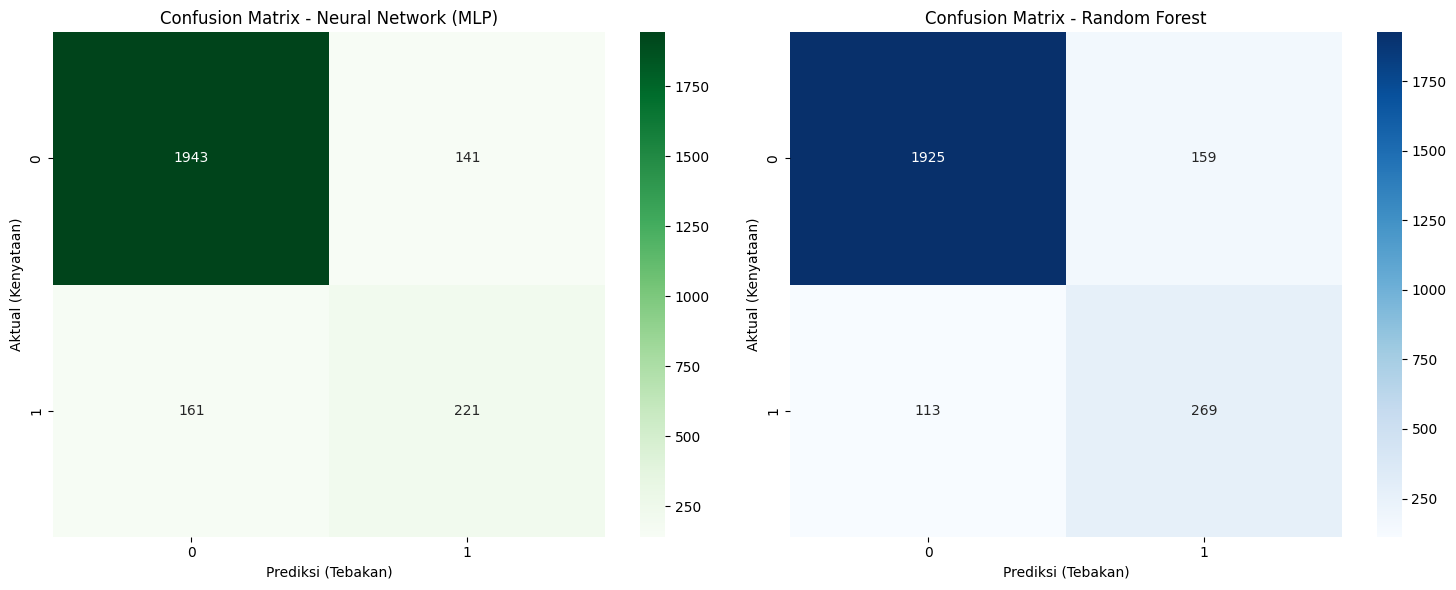

In [12]:
import pandas as pd
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 1. LOAD DATA
df = pd.read_csv("online_shoppers_intention.csv")

# 2. PREPROCESSING
y = df["Revenue"].astype(int)
X = pd.get_dummies(df.drop("Revenue", axis=1))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE (Menyeimbangkan Data)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. DEFINISI MODEL & PIPELINE
models = {
    "Neural Network (MLP)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu', 
                              max_iter=500, early_stopping=True, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1))
    ])
}

# 4. EKSEKUSI & EVALUASI
results_list = []
preds_dict = {} # Untuk menyimpan hasil prediksi masing-masing model

print("--- Memulai Pelatihan Model ---")
for name, pipe in models.items():
    start_t = time.time()
    pipe.fit(X_train_res, y_train_res)
    train_time = time.time() - start_t
    
    # Simpan Prediksi
    preds = pipe.predict(X_test)
    preds_dict[name] = preds
    
    acc = accuracy_score(y_test, preds)
    results_list.append({
        "Model": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Train Time (s)": round(train_time, 3)
    })
    print(f"Selesai melatih: {name}")

# 5. TAMPILKAN TABEL HASIL
results_df = pd.DataFrame(results_list)
print("\n=== TABEL PERBANDINGAN FINAL ===")
print(results_df.to_string(index=False))

# 6. VISUALISASI CONFUSION MATRIX BERDAMPINGAN
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix MLP (Hijau)
cm_mlp = confusion_matrix(y_test, preds_dict["Neural Network (MLP)"])
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix - Neural Network (MLP)')
ax[0].set_ylabel('Aktual (Kenyataan)')
ax[0].set_xlabel('Prediksi (Tebakan)')

# Confusion Matrix Random Forest (Biru)
cm_rf = confusion_matrix(y_test, preds_dict["Random Forest"])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix - Random Forest')
ax[1].set_ylabel('Aktual (Kenyataan)')
ax[1].set_xlabel('Prediksi (Tebakan)')

plt.tight_layout()
plt.show()

# PERBANDINGAN MODEL: MLP vs Random Forest (FINAL & RAPI)

In [ ]:
import pandas as pd
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

print("="*60)
print("PERBANDINGAN: NEURAL NETWORK (MLP) vs RANDOM FOREST")
print("="*60)

# ==================================================
# 1. LOAD DATA
# ==================================================
print("\n[1] Loading data...")
df = pd.read_csv("online_shoppers_intention.csv")
print(f"   ✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ==================================================
# 2. PREPROCESSING
# ==================================================
print("\n[2] Preprocessing data...")

# Target variable
y = df["Revenue"].astype(int)

# Features dengan one-hot encoding
X = pd.get_dummies(df.drop("Revenue", axis=1))
print(f"   ✓ Features after encoding: {X.shape[1]} features")

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   ✓ Train set: {X_train.shape[0]} samples")
print(f"   ✓ Test set: {X_test.shape[0]} samples")

# Handle imbalanced data dengan SMOTE
print(f"\n   Before SMOTE - Class distribution:")
print(f"   {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\n   After SMOTE - Class distribution:")
print(f"   {pd.Series(y_train_res).value_counts().to_dict()}")

# ==================================================
# 3. DEFINISI MODEL & PIPELINE
# ==================================================
print("\n[3] Defining models...")

models = {
    "Neural Network (MLP)": Pipeline([
        ('scaler', StandardScaler()),  # Scaling WAJIB untuk MLP
        ('clf', MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation='relu',
            solver='adam',
            max_iter=500,
            early_stopping=True,
            alpha=0.0001,
            learning_rate_init=0.001,
            random_state=42,
            validation_fraction=0.1
        ))
    ]),
    
    "Random Forest": Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

print("   ✓ Models defined successfully")

# ==================================================
# 4. EKSEKUSI & EVALUASI
# ==================================================
print("\n[4] Training and evaluating models...\n")

final_results = []
preds_dict = {}

for name, pipe in models.items():
    print(f"   Training: {name}...")
    
    # Training phase
    start_train = time.time()
    pipe.fit(X_train_res, y_train_res)
    train_time = time.time() - start_train
    
    # Prediction phase
    start_pred = time.time()
    preds = pipe.predict(X_test)
    pred_time = time.time() - start_pred
    
    # Store predictions for confusion matrix
    preds_dict[name] = preds
    
    # Calculate accuracy
    acc = accuracy_score(y_test, preds)
    
    final_results.append({
        "Model": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Train Time (s)": round(train_time, 3),
        "Predict Time (s)": round(pred_time, 5)
    })
    
    print(f"   ✓ Selesai: Accuracy = {acc*100:.2f}%")

# ==================================================
# 5. TAMPILKAN TABEL PERBANDINGAN
# ==================================================
print("\n" + "="*60)
print("TABEL PERBANDINGAN HASIL")
print("="*60)

results_df = pd.DataFrame(final_results)
print(results_df.to_string(index=False))
print("="*60)

## Confusion Matrix Visualization

In [ ]:
# ==================================================
# 6. VISUALISASI CONFUSION MATRIX BERDAMPINGAN
# ==================================================
print("\n[5] Generating confusion matrix visualizations...\n")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix MLP (Warna Hijau)
cm_mlp = confusion_matrix(y_test, preds_dict["Neural Network (MLP)"])
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens', ax=ax[0], 
            cbar_kws={'label': 'Count'})
ax[0].set_title('Confusion Matrix - Neural Network (MLP)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Aktual (Kenyataan)', fontsize=11)
ax[0].set_xlabel('Prediksi (Tebakan)', fontsize=11)
ax[0].set_xticklabels(['Tidak Beli (0)', 'Beli (1)'])
ax[0].set_yticklabels(['Tidak Beli (0)', 'Beli (1)'])

# Confusion Matrix Random Forest (Warna Biru)
cm_rf = confusion_matrix(y_test, preds_dict["Random Forest"])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            cbar_kws={'label': 'Count'})
ax[1].set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Aktual (Kenyataan)', fontsize=11)
ax[1].set_xlabel('Prediksi (Tebakan)', fontsize=11)
ax[1].set_xticklabels(['Tidak Beli (0)', 'Beli (1)'])
ax[1].set_yticklabels(['Tidak Beli (0)', 'Beli (1)'])

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## Detailed Classification Report

In [ ]:
# ==================================================
# 7. CLASSIFICATION REPORT DETAIL
# ==================================================
print("\n" + "="*60)
print("CLASSIFICATION REPORT - NEURAL NETWORK (MLP)")
print("="*60)
print(classification_report(y_test, preds_dict["Neural Network (MLP)"], 
                          target_names=['Tidak Beli (0)', 'Beli (1)']))

print("\n" + "="*60)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*60)
print(classification_report(y_test, preds_dict["Random Forest"],
                          target_names=['Tidak Beli (0)', 'Beli (1)']))

# ==================================================
# 8. RINGKASAN CONFUSION MATRIX UNTUK LAPORAN
# ==================================================
print("\n" + "="*60)
print("ANALISIS CONFUSION MATRIX - MLP")
print("="*60)
tn_mlp, fp_mlp, fn_mlp, tp_mlp = cm_mlp.ravel()
print(f"True Negative  (Benar Prediksi: Tidak Beli)  : {tn_mlp}")
print(f"True Positive  (Benar Prediksi: Beli)        : {tp_mlp}")
print(f"False Positive (Salah Prediksi: Tidak → Beli): {fp_mlp}")
print(f"False Negative (Salah Prediksi: Beli → Tidak): {fn_mlp}")

print("\n" + "="*60)
print("ANALISIS CONFUSION MATRIX - RANDOM FOREST")
print("="*60)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"True Negative  (Benar Prediksi: Tidak Beli)  : {tn_rf}")
print(f"True Positive  (Benar Prediksi: Beli)        : {tp_rf}")
print(f"False Positive (Salah Prediksi: Tidak → Beli): {fp_rf}")
print(f"False Negative (Salah Prediksi: Beli → Tidak): {fn_rf}")

print("\n" + "="*60)
print("✓ ANALISIS SELESAI - SIAP UNTUK LAPORAN")
print("="*60)